# Phase 3: Model Diagnostics and Validation

| | |
|---|---|
| **Notebook** | Phase3_Model_Diagnostics_and_Validation.ipynb |
| **Author** | Ashok Kumar Bhairwal |
| **Course** | Applied Probability and Statistics for AI (AAI-500-IN1) |
| **Dataset** | Credit Risk Modeling Dataset |
| **Phase** | Phase 3 - Model Diagnostics |
| **Date** | June 14, 2026 |
| **GitHub** | https://github.com/diaeshantony-usd/applied-statistics-and-ai-team-project |

## Objectives

This notebook performs comprehensive diagnostics and validation for the machine learning models selected in Phase 2 (B2_Statistics_Modeling_and_Inference.ipynb).

**Models Under Evaluation:**
- **Classification**: CatBoost Classifier (default prediction)
- **Regression**: Best-performing regressors for loan amount, loan percent income, and interest rate

**Diagnostic Scope:**

1. **Classification Diagnostics:**
   - ROC Curve and Precision-Recall Analysis
   - Calibration Analysis (Reliability Diagram)
   - Confusion Matrix Analysis
   - Error Analysis by Segments
   - Feature Importance (SHAP Values)

2. **Regression Diagnostics:**
   - Residual Analysis (Interest Rate Model)
   - Predicted vs Actual Analysis
   - Performance by Segments (Loan Grade)
   - Feature Importance (SHAP Analysis - Interest Rate)

---

## **1. Initialization and Resource Loading**

##  **1.1 Setup and Configuration**

In [1]:
!pip install xgboost
!pip install lightgbm
!pip install shap 
!pip install catboost


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


In [14]:
# Core data libraries
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import xgboost
import lightgbm

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Scikit-learn metrics and diagnostics
from sklearn.metrics import (
    # Classification metrics
    roc_curve, auc, precision_recall_curve,
    confusion_matrix, classification_report,
    roc_auc_score, brier_score_loss,
    # Regression metrics
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve, cross_val_score

import shap


# Configuration
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# File paths
PHASE2_DATA_PATH = "data/processed/phase2/credit_risk_cleaned.csv"
CLASSIFICATION_MODEL_DIR = Path("data/models/classification")
REGRESSION_MODEL_DIR = Path("data/models/regression")

# Test size (must match Phase 2)
TEST_SIZE = 0.20

# Custom threshold classifier (required to load saved models from B2)
# This class was defined in B2 and is needed to unpickle best_default_classifier.joblib

DEFAULT_DECISION_THRESHOLD = 0.50

class ThresholdClassifier:
    """
    Custom threshold classifier wrapper for applying non-default decision thresholds.
    
    This class wraps a probabilistic classifier and applies a custom threshold
    for converting probabilities to class predictions. Used in B2 for threshold
    tuning (0.24 vs default 0.50) based on business cost optimization.
    
    Required for deserializing the saved best_default_classifier.joblib model.
    """
    def __init__(self, model, threshold=DEFAULT_DECISION_THRESHOLD):
        """
        Initialize threshold classifier.
        
        Parameters:
        -----------
        model : estimator
            A fitted classifier with predict_proba method
        threshold : float, default=0.50
            Decision threshold for converting probabilities to predictions
        """
        self.model = model
        self.threshold = threshold

    def predict_proba(self, X):
        """
        Return probability predictions from underlying model.
        
        Parameters:
        -----------
        X : array-like
            Feature matrix
            
        Returns:
        --------
        array : Probability predictions [P(class=0), P(class=1)]
        """
        return self.model.predict_proba(X)

    def predict(self, X):
        """
        Apply custom threshold to probability predictions.
        
        Parameters:
        -----------
        X : array-like
            Feature matrix
            
        Returns:
        --------
        array : Binary predictions (0 or 1)
        """
        default_probability = self.predict_proba(X)[:, 1]
        return (default_probability >= self.threshold).astype(int)


print("\n Configuration:")
print(f"[INFO] Data: {PHASE2_DATA_PATH}")
print(f"[INFO] Classification models: {CLASSIFICATION_MODEL_DIR}")
print(f"[INFO] Regression models: {REGRESSION_MODEL_DIR}")
print(f"[INFO] Test size: {TEST_SIZE*100:.0f}%")
print("[INFO] ThresholdClassifier class loaded (threshold support enabled)")


 Configuration:
[INFO] Data: data/processed/phase2/credit_risk_cleaned.csv
[INFO] Classification models: data\models\classification
[INFO] Regression models: data\models\regression
[INFO] Test size: 20%
[INFO] ThresholdClassifier class loaded (threshold support enabled)


---
##  **1.2 Load Data and Models**

Load the Phase 2 dataset and the saved best models for diagnostic analysis.

In [16]:
# Load Phase 2 dataset
df_model = pd.read_csv(PHASE2_DATA_PATH)

# Restore ordered category labels for grouped features
group_category_orders = {
    "income_group": ["Low", "Lower-Middle", "Middle", "Upper-Middle", "High"],
    "loan_amount_group": ["Small", "Medium", "Large", "Very Large"],
    "loan_percent_income_group": ["Low Burden", "Moderate Burden", "High Burden", "Very High Burden"],
    "age_group": ["Young", "Adult", "Experienced Adult"],
}
for column_name, category_order in group_category_orders.items():
    if column_name in df_model.columns:
        df_model[column_name] = pd.Categorical(
            df_model[column_name],
            categories=category_order,
            ordered=True,
        )

print(f"[INFO] Phase 2 dataset loaded \nShape: {df_model.shape} ,  Features: {df_model.shape[1]} , Samples: {df_model.shape[0]:,} ")


# Helper function to load saved models
def load_model(model_dir, filename):
    """Load a saved model from joblib file."""
    path = Path(model_dir) / filename
    if not path.exists():
        raise FileNotFoundError(f"Model not found: {path}")
    return joblib.load(path)

# Load best classification model
best_classifier = load_model(CLASSIFICATION_MODEL_DIR, "best_default_classifier.joblib")
print("[INFO] Best classification model loaded:\n - best_default_classifier.joblib")

# Load best regression models
best_loan_amount_model = load_model(REGRESSION_MODEL_DIR, "best_loan_amount_regressor.joblib")
best_loan_percent_model = load_model(REGRESSION_MODEL_DIR, "best_loan_percent_income_regressor.joblib")
best_interest_rate_model = load_model(REGRESSION_MODEL_DIR, "best_interest_rate_regressor.joblib")

print("[INFO] Following regression model loaded: \n - best_loan_amount_regressor.joblib \n - best_loan_percent_income_regressor.joblib \n - best_interest_rate_regressor.joblib")

[INFO] Phase 2 dataset loaded 
Shape: (29567, 23) ,  Features: 23 , Samples: 29,567 
[INFO] Best classification model loaded:
 - best_default_classifier.joblib
[INFO] Following regression model loaded: 
 - best_loan_amount_regressor.joblib 
 - best_loan_percent_income_regressor.joblib 
 - best_interest_rate_regressor.joblib


---
##  **2. Diagnostic Test Data Preparation**

Recreate the original train/test split to ensure consistent model diagnostics and evaluation.

###  **2.1 Defining Features**

In [19]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Define feature columns (must match Phase 2 - including engineered features from B1)
numeric_cols = [
    "person_age", "person_income", "person_emp_length",
    "loan_amnt", "loan_percent_income", "loan_int_rate",
    "cb_person_cred_hist_length",
    "log_person_income", "log_loan_amnt",
    "income_to_loan_ratio", "employment_to_age_ratio",
    "credit_history_to_age_ratio",
    "loan_grade_numeric",  # Added: numeric encoding of loan_grade
]

nominal_cols = ["person_home_ownership", "loan_intent"]

binary_cols = [
    "cb_person_default_on_file",
    "default_on_file_binary",  # Added: binary version of default_on_file
]

ordinal_cols = ["loan_grade"]

# Grouped categorical features from B1 feature engineering
grouped_cols = [
    "income_group",
    "loan_amount_group",
    "loan_percent_income_group",
    "age_group",
]

classification_target = "loan_status"
classification_feature_cols = numeric_cols + nominal_cols + binary_cols + ordinal_cols + grouped_cols

regression_feature_cols = [
    "person_age", "person_income", "person_home_ownership",
    "person_emp_length", "loan_intent", "loan_grade",
    "cb_person_default_on_file", "cb_person_cred_hist_length",
    "log_person_income", "income_to_loan_ratio",
    "employment_to_age_ratio", "credit_history_to_age_ratio",
    "default_on_file_binary",  
    "income_group",  
    "age_group"
]

print("✅ Feature columns defined")
print(f"   Classification features: {len(classification_feature_cols)}")
print(f"   Regression features: {len(regression_feature_cols)}")
print(f"   Grouped features: {len(grouped_cols)}")

✅ Feature columns defined
   Classification features: 22
   Regression features: 15
   Grouped features: 4


----
###  **2.2 Classification data**






In [25]:
from tabulate import tabulate

# Classification train/test split
X_cls = df_model[classification_feature_cols].copy()
y_cls = df_model[classification_target].copy()

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_cls
)

summary_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Samples": [X_train_cls.shape[0], X_test_cls.shape[0]],
    "Split (%)": [(1 - TEST_SIZE) * 100, TEST_SIZE * 100],
    "Default Rate (%)": [y_train_cls.mean() * 100, y_test_cls.mean() * 100]
})

summary_df["Samples"] = summary_df["Samples"].map("{:,}".format)
summary_df["Split (%)"] = summary_df["Split (%)"].map("{:.0f}%".format)
summary_df["Default Rate (%)"] = summary_df["Default Rate (%)"].map("{:.2f}%".format)

print(f"[INFO]  Classification data for training and test")

print(tabulate(summary_df, headers="keys", tablefmt="grid", showindex=False))


[INFO]  Classification data for training and test
+-----------+-----------+-------------+--------------------+
| Dataset   | Samples   | Split (%)   | Default Rate (%)   |
+===========+===========+=============+====================+
| Train     | 23,653    | 80%         | 22.45%             |
+-----------+-----------+-------------+--------------------+
| Test      | 5,914     | 20%         | 22.44%             |
+-----------+-----------+-------------+--------------------+


----
###  **2.3 Regression data**

In [27]:
# Regression data (non-default loans only, matching Phase 2)
df_regression = df_model[df_model[classification_target] == 0].copy().reset_index(drop=True)

X_reg = df_regression[regression_feature_cols].copy()
y_loan_amount = df_regression["loan_amnt"].copy()
y_loan_percent = df_regression["loan_percent_income"].copy()
y_interest_rate = df_regression["loan_int_rate"].copy()

# Split regression data
X_reg_train, X_reg_test, y_amt_train, y_amt_test = train_test_split(
    X_reg, y_loan_amount, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
_, _, y_pct_train, y_pct_test = train_test_split(
    X_reg, y_loan_percent, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
_, _, y_rate_train, y_rate_test = train_test_split(
    X_reg, y_interest_rate, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

regression_summary = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Samples": [X_reg_train.shape[0], X_reg_test.shape[0]],
    "Target Variables": [
        "loan_amnt, loan_percent_income, loan_int_rate",
        "loan_amnt, loan_percent_income, loan_int_rate"
    ]
})

regression_summary

print(f"[INFO]  Regression Data Split (Non-default loans only)")

print(tabulate(regression_summary, headers="keys", tablefmt="grid", showindex=False))

[INFO]  Regression Data Split (Non-default loans only)
+-----------+-----------+-----------------------------------------------+
| Dataset   |   Samples | Target Variables                              |
+===========+===========+===============================================+
| Train     |     18344 | loan_amnt, loan_percent_income, loan_int_rate |
+-----------+-----------+-----------------------------------------------+
| Test      |      4587 | loan_amnt, loan_percent_income, loan_int_rate |
+-----------+-----------+-----------------------------------------------+


---
## 3. Classification Model Diagnostics

Comprehensive diagnostics for the CatBoost classifier (default prediction).

### 3.1 ROC Curve and Precision-Recall Analysis

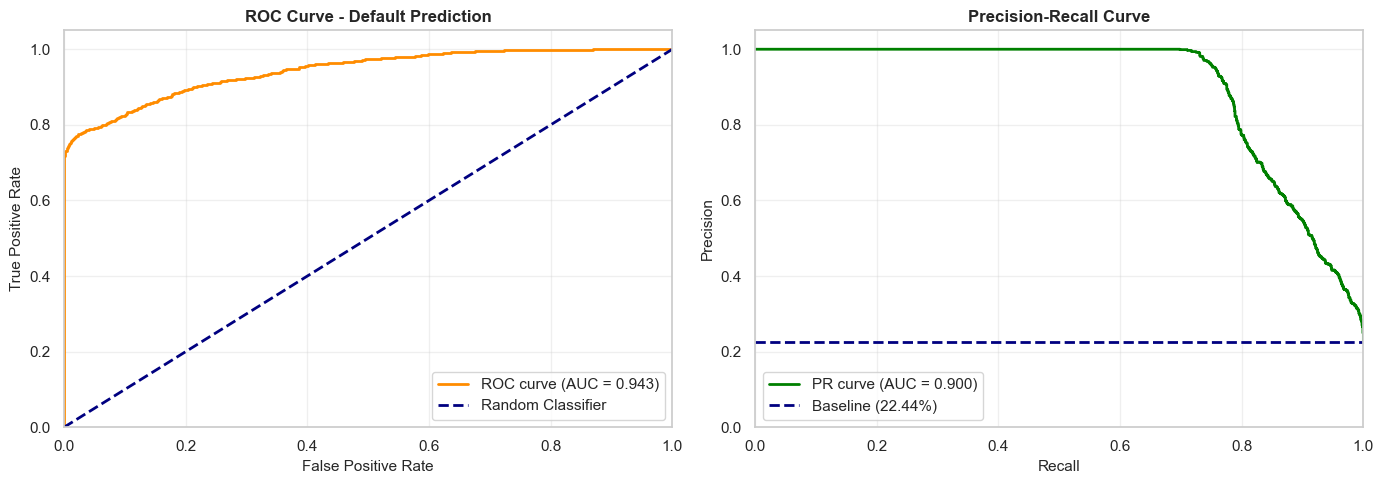


[INFO] ROC and Precision-Recall Analysis:
   ROC-AUC: 0.9429
   PR-AUC:  0.9003


In [35]:
# Get predictions and probabilities
y_pred_cls = best_classifier.predict(X_test_cls)
y_prob_cls = best_classifier.predict_proba(X_test_cls)[:, 1]

# Calculate ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test_cls, y_prob_cls)
roc_auc = auc(fpr, tpr)

# Calculate Precision-Recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_test_cls, y_prob_cls)
pr_auc = auc(recall, precision)

# Plot both curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve - Default Prediction', fontsize=12, fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
baseline = y_test_cls.mean()
axes[1].axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline:.2%})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[INFO] ROC and Precision-Recall Analysis:")
print(f"   ROC-AUC: {roc_auc:.4f}")
print(f"   PR-AUC:  {pr_auc:.4f}")

# Explanation : 

### **1.  ROC Curve and ROC-AUC Analysis**

The Receiver Operating Characteristic (ROC) Curve evaluates the performance of a binary classification model across all possible classification thresholds. It plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)**, providing insight into the model's ability to distinguish between default and non-default loans.

The two key metrics used in constructing the ROC Curve are:

#### True Positive Rate (TPR) / Recall

The True Positive Rate measures the proportion of actual defaulted loans that are correctly identified by the model.

$$ TPR = \frac{TP}{TP + FN} $$


Where:

* **TP (True Positives):** Defaulted loans correctly classified as defaults.
* **FN (False Negatives):** Defaulted loans incorrectly classified as non-defaults.

#### False Positive Rate (FPR)

The False Positive Rate measures the proportion of non-defaulted loans that are incorrectly classified as defaults.

$$ FPR = \frac{FP}{FP + TN} $$

Where:

* **FP (False Positives):** Non-defaulted loans incorrectly classified as defaults.
* **TN (True Negatives):** Non-defaulted loans correctly classified as non-defaults.

By varying the classification threshold and plotting TPR against FPR, the ROC Curve illustrates the trade-off between correctly identifying defaults and minimizing false alarms.

#### ROC-AUC Score

The model achieved a **ROC-AUC score of 0.9429**, indicating excellent classification performance. This means there is a **94.29% probability** that the model will assign a higher risk score to a defaulted borrower than to a non-defaulted borrower. The high ROC-AUC value demonstrates the model's strong ability to distinguish between high-risk and low-risk loan applicants.


### **2. Precision-Recall Curve Analysis**

The Precision-Recall (PR) Curve evaluates a model's performance by examining the trade-off between **Precision** and **Recall** across different classification thresholds. It is particularly useful for imbalanced datasets, such as credit risk prediction, where defaulted loans are less common than non-defaulted loans.

#### Precision

Precision measures the proportion of loans predicted as defaults that actually defaulted.

$$
Precision = \frac{TP}{TP + FP}
$$

Where:

* **TP (True Positives):** Defaulted loans correctly identified as defaults.
* **FP (False Positives):** Non-defaulted loans incorrectly identified as defaults.

#### Recall

Recall measures the proportion of actual defaulted loans that are correctly identified by the model.

$$
Recall = \frac{TP}{TP + FN}
$$

Where:

* **FN (False Negatives):** Defaulted loans incorrectly identified as non-defaults.

#### Average Precision (AP) Score

The model achieved a **PR-AUC score of 0.9003**, indicating excellent performance in identifying defaulted loans while maintaining a low rate of false positives. This high score demonstrates that the model effectively balances precision and recall, making it well-suited for detecting high-risk borrowers and supporting accurate credit risk assessment.



-----

### 3.2 Calibration Analysis (Reliability Diagram)

Check if predicted probabilities match actual default rates.

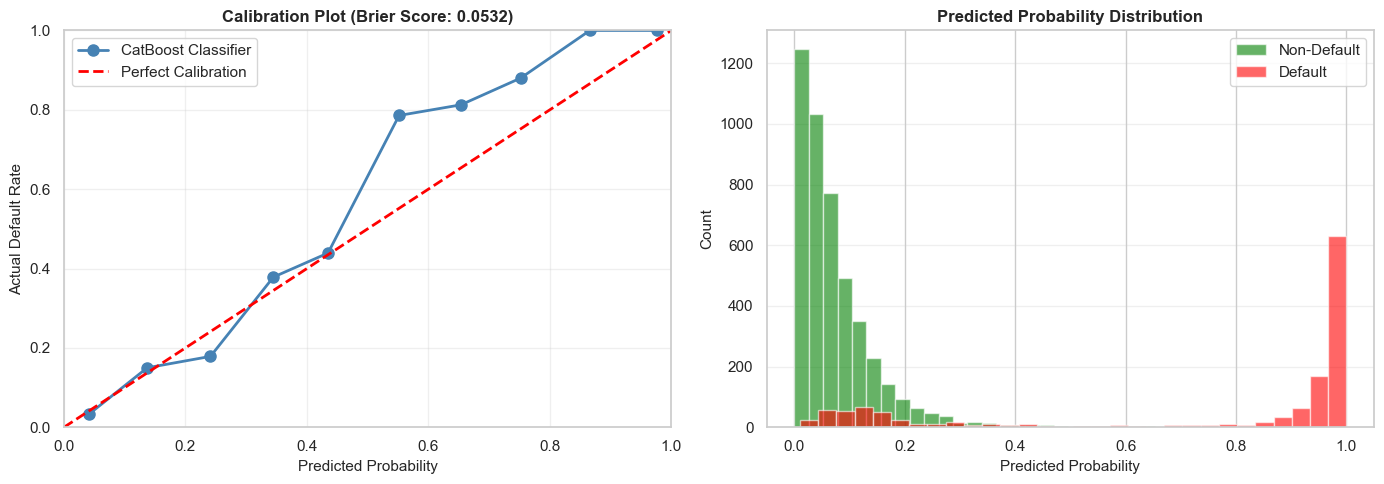


📊 Calibration Analysis:
   Brier Score: 0.0532 (0=perfect, 1=worst)

   Interpretation:
   - Points on diagonal = well-calibrated predictions
   - Above diagonal = model is under-confident
   - Below diagonal = model is over-confident

   Mean Calibration Error: 0.0800
   ✅ Good calibration (error < 10%)


In [31]:
# Calculate calibration curve
prob_true, prob_pred = calibration_curve(y_test_cls, y_prob_cls, n_bins=10, strategy='uniform')

# Calculate Brier score (lower is better)
brier = brier_score_loss(y_test_cls, y_prob_cls)

# Plot calibration curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration plot
axes[0].plot(prob_pred, prob_true, marker='o', markersize=8, linewidth=2, 
             color='steelblue', label='CatBoost Classifier')
axes[0].plot([0, 1], [0, 1], linestyle='--', linewidth=2, color='red', 
             label='Perfect Calibration')
axes[0].set_xlabel('Predicted Probability', fontsize=11)
axes[0].set_ylabel('Actual Default Rate', fontsize=11)
axes[0].set_title(f'Calibration Plot (Brier Score: {brier:.4f})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Probability distribution histogram
axes[1].hist(y_prob_cls[y_test_cls == 0], bins=30, alpha=0.6, label='Non-Default', color='green')
axes[1].hist(y_prob_cls[y_test_cls == 1], bins=30, alpha=0.6, label='Default', color='red')
axes[1].set_xlabel('Predicted Probability', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Predicted Probability Distribution', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Calibration Analysis:")
print(f"   Brier Score: {brier:.4f} (0=perfect, 1=worst)")
print(f"\n   Interpretation:")
print(f"   - Points on diagonal = well-calibrated predictions")
print(f"   - Above diagonal = model is under-confident")
print(f"   - Below diagonal = model is over-confident")

# Calculate calibration error
calibration_error = np.mean(np.abs(prob_true - prob_pred))
print(f"\n   Mean Calibration Error: {calibration_error:.4f}")
if calibration_error < 0.05:
    print("   ✅ Excellent calibration (error < 5%)")
elif calibration_error < 0.10:
    print("   ✅ Good calibration (error < 10%)")
else:
    print("   ⚠️  Moderate calibration - consider calibration techniques")

# Explanation


## Calibration Analysis (Reliability Diagram)

Calibration Analysis assesses how closely the predicted default probabilities align with the observed default rates.

### Brier Score

The Brier Score measures the accuracy of probabilistic predictions:

$$
\text{Brier Score} = \frac{1}{N}\sum_{i=1}^{N}(p_i-y_i)^2
$$


Where $p_i$ is the predicted probability and $y_i$ is the actual outcome.

The Brier Score ranges from **0 to 1**, where:

* **0** = Perfect calibration
* **Lower values** = Better probability estimates
* **Higher values** = Poorer calibration

The model achieved a **Brier Score of 0.0532**, indicating excellent calibration and highly accurate probability predictions.

### Mean Calibration Error

The model achieved a **Mean Calibration Error of 0.0800 (8.0%)**, which measures the average difference between predicted probabilities and actual outcomes. Lower values indicate better calibration.

Since the calibration error is below **10%**, the model demonstrates **good calibration**, suggesting that its predicted probabilities closely reflect real-world default frequencies.



-----

### 3.3 Confusion Matrix Analysis

Analyze classification errors at multiple thresholds.

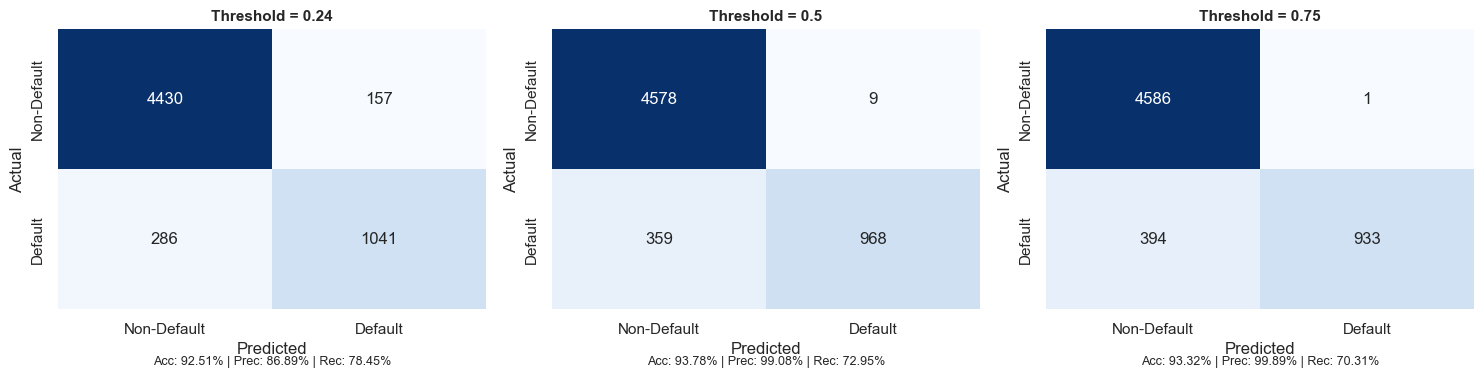

+-------------+------------+-------------+----------+------------+
|   Threshold |   Accuracy |   Precision |   Recall |   F1-Score |
+=============+============+=============+==========+============+
|        0.24 |     0.9251 |      0.8689 |   0.7845 |     0.8246 |
+-------------+------------+-------------+----------+------------+
|        0.5  |     0.9378 |      0.9908 |   0.7295 |     0.8403 |
+-------------+------------+-------------+----------+------------+
|        0.75 |     0.9332 |      0.9989 |   0.7031 |     0.8253 |
+-------------+------------+-------------+----------+------------+


In [34]:
# Test multiple thresholds
thresholds_to_test = [0.24, 0.50, 0.75]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, threshold in enumerate(thresholds_to_test):
    # Apply threshold
    y_pred_threshold = (y_prob_cls >= threshold).astype(int)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test_cls, y_pred_threshold)
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'],
                ax=axes[idx], cbar=False)
    
    axes[idx].set_title(f'Threshold = {threshold}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')
    
    # Add metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    axes[idx].text(0.5, -0.2, f'Acc: {accuracy:.2%} | Prec: {precision:.2%} | Rec: {recall:.2%}',
                   ha='center', transform=axes[idx].transAxes, fontsize=9)

plt.tight_layout()
plt.show()

results = []

for threshold in thresholds_to_test:
    y_pred_threshold = (y_prob_cls >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test_cls, y_pred_threshold),
        "Precision": precision_score(y_test_cls, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test_cls, y_pred_threshold, zero_division=0),
        "F1-Score": f1_score(y_test_cls, y_pred_threshold, zero_division=0)
    })

# Create DataFrame
confusion_metrics_df = pd.DataFrame(results)

# Format for display
confusion_metrics_df = confusion_metrics_df.round(4)

print(tabulate(confusion_metrics_df, headers="keys", tablefmt="grid", showindex=False))

# Explanation:

The Confusion Matrix metrics demonstrate the trade-off between Precision and Recall across different classification thresholds. As the threshold increases, Precision improves while Recall decreases, indicating that the model becomes more conservative in predicting defaults.

Among the evaluated thresholds, **0.50** provides the best overall performance, achieving the **highest Accuracy (93.78%) and F1-Score (0.8403)** while maintaining excellent **Precision (99.08%) and strong Recall (72.95%)**. This balance suggests that the model effectively identifies defaulted loans while minimizing false-positive predictions, making **0.50** the most suitable threshold for credit risk classification.

----
### 3.4 Error Analysis by Segments

Analyze where the model makes mistakes.

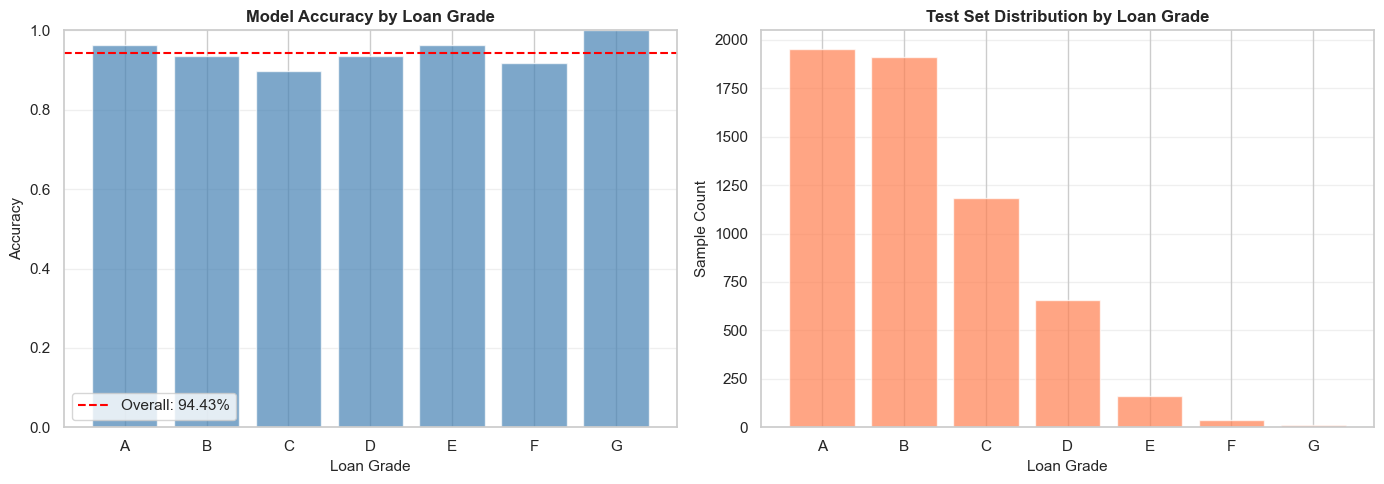


 Error Analysis by Loan Grade:
+--------------+------------+---------+----------------+
| loan_grade   |   Accuracy |   Count |   Default_Rate |
+==============+============+=========+================+
| A            |     0.9641 |    1951 |         0.102  |
+--------------+------------+---------+----------------+
| B            |     0.9352 |    1914 |         0.1808 |
+--------------+------------+---------+----------------+
| C            |     0.897  |    1184 |         0.2086 |
+--------------+------------+---------+----------------+
| D            |     0.9347 |     658 |         0.5988 |
+--------------+------------+---------+----------------+
| E            |     0.9623 |     159 |         0.6289 |
+--------------+------------+---------+----------------+
| F            |     0.9167 |      36 |         0.8056 |
+--------------+------------+---------+----------------+
| G            |     1      |      12 |         1      |
+--------------+------------+---------+----------------+

In [44]:
# Create error analysis dataframe
error_df = X_test_cls.copy()
error_df['actual'] = y_test_cls.values
error_df['predicted'] = y_pred_cls
error_df['probability'] = y_prob_cls
error_df['correct'] = (error_df['actual'] == error_df['predicted'])

# Error rates by loan grade
error_by_grade = error_df.groupby('loan_grade').agg({
    'correct': 'mean',
    'actual': ['count', 'mean']
}).round(4)
error_by_grade.columns = ['Accuracy', 'Count', 'Default_Rate']
error_by_grade = error_by_grade.sort_index()

# Plot error analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy by loan grade
axes[0].bar(error_by_grade.index, error_by_grade['Accuracy'], color='steelblue', alpha=0.7)
axes[0].axhline(y=error_by_grade['Accuracy'].mean(), color='red', linestyle='--', 
                label=f"Overall: {error_by_grade['Accuracy'].mean():.2%}")
axes[0].set_xlabel('Loan Grade', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Model Accuracy by Loan Grade', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 1])

# Sample size by grade
axes[1].bar(error_by_grade.index, error_by_grade['Count'], color='coral', alpha=0.7)
axes[1].set_xlabel('Loan Grade', fontsize=11)
axes[1].set_ylabel('Sample Count', fontsize=11)
axes[1].set_title('Test Set Distribution by Loan Grade', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n Error Analysis by Loan Grade:")
print(tabulate(error_by_grade, headers="keys", tablefmt="grid", showindex=True))

print(f"\n[INFO]  Overall Accuracy: {error_by_grade['Accuracy'].mean():.2%}")
print(f"[INFO]  Best Grade: {error_by_grade['Accuracy'].idxmax()} ({error_by_grade['Accuracy'].max():.2%})")
print(f"[INFO]  Worst Grade: {error_by_grade['Accuracy'].idxmin()} ({error_by_grade['Accuracy'].min():.2%})")


## Error Analysis by Loan Grade

The model achieved an overall accuracy of **94.43%** across all loan grades, demonstrating strong predictive performance. Accuracy remained above **89% **across all grades, with the highest for **Grade G (100.00%) and the lowest for Grade C (89.70%)**. Default rates increased consistently **from 10.20% for Grade A to 100.00% for Grade G**, reflecting the higher risk associated with lower credit grades. Overall, the model performed reliably across different loan grades, with only a slight decrease in accuracy for mid-risk borrowers.

----

### 3.5 Feature Importance - SHAP Analysis

Understand which features drive default predictions using SHAP values.

[INFO] Computing SHAP values for classification model...it may take few mins 



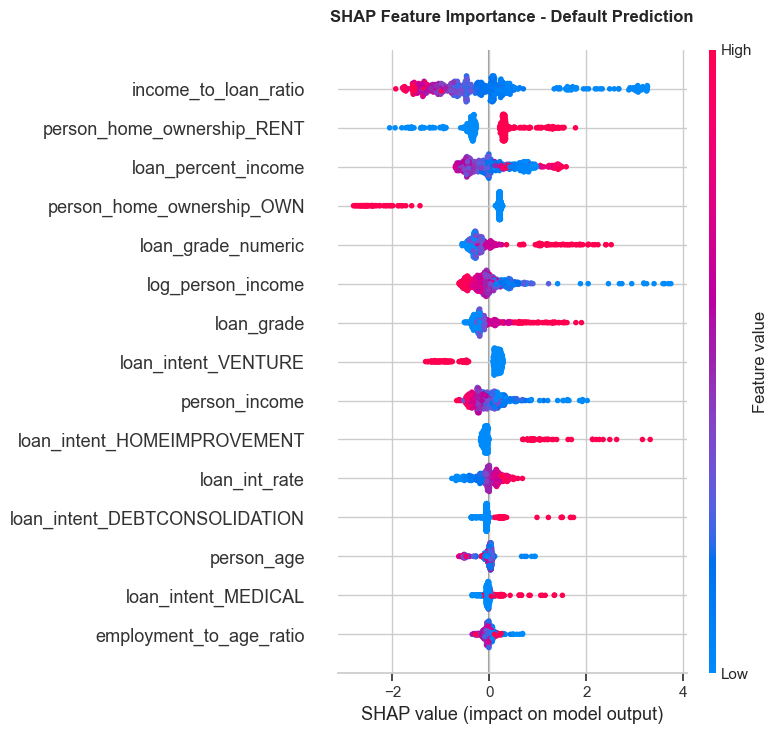


[INFO] SHAP analysis completed
   Interpretation:
   - Features at top have highest impact on predictions
   - Red = high feature value, Blue = low feature value
   - Right of zero = increases default probability


In [56]:
print("[INFO] Computing SHAP values for classification model...it may take few mins \n")
    
# Sample data for SHAP (using subset for speed)
sample_size = min(500, len(X_test_cls))
X_shap_sample = X_test_cls.sample(n=sample_size, random_state=RANDOM_STATE)

# Create SHAP explainer
# Note: For CatBoost with pipeline, we need to transform first
# Get the underlying model from the pipeline/wrapper
if hasattr(best_classifier, 'model'):
    base_model = best_classifier.model
else:
    base_model = best_classifier
    
# Transform data through preprocessing
if hasattr(base_model, 'named_steps'):
    preprocessor = base_model.named_steps['preprocess']
    estimator = base_model.named_steps.get('model', base_model.named_steps.get('estimator'))  # ← FIXED
    X_transformed = preprocessor.transform(X_shap_sample)
        # Get feature names after preprocessing
    try:
        feature_names = preprocessor.get_feature_names_out()
         # Clean up prefixes like 'nom__', 'num__', 'ord__', 'bin__' from ColumnTransformer
        feature_names = [name.split('__', 1)[-1] if '__' in name else name for name in feature_names]
    except:
            # Fallback if get_feature_names_out not available
        feature_names = [f"feature_{i}" for i in range(X_transformed.shape[1])]
        
        # Convert to DataFrame with feature names
    X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

else:
    X_transformed_df = X_shap_sample
    estimator = base_model
    
try:
# Create TreeExplainer for tree-based models
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_transformed_df)

# For binary classification, shap_values might be a list
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # Use positive class

# Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_transformed_df, show=False, max_display=15)
    plt.title('SHAP Feature Importance - Default Prediction', fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    print("\n[INFO] SHAP analysis completed")
    print("   Interpretation:")
    print("   - Features at top have highest impact on predictions")
    print("   - Red = high feature value, Blue = low feature value")
    print("   - Right of zero = increases default probability")
    
except Exception as e:
    print(f"[ERROR]  SHAP analysis failed: {e}")
    print("   Falling back to built-in feature importance...")
    
    # Use permutation importance as fallback
    perm_importance = permutation_importance(
        best_classifier, X_test_cls, y_test_cls, 
        n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
    )
    
    importance_df = pd.DataFrame({
        'feature': classification_feature_cols,
        'importance': perm_importance.importances_mean
    }).sort_values('importance', ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'], importance_df['importance'])
    plt.xlabel('Permutation Importance')
    plt.title('Feature Importance (Permutation)', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 4. Regression Model Diagnostics

Comprehensive diagnostics for regression models (loan amount, loan percent income, interest rate).

### 4.1 Residual Analysis - Interest Rate Model

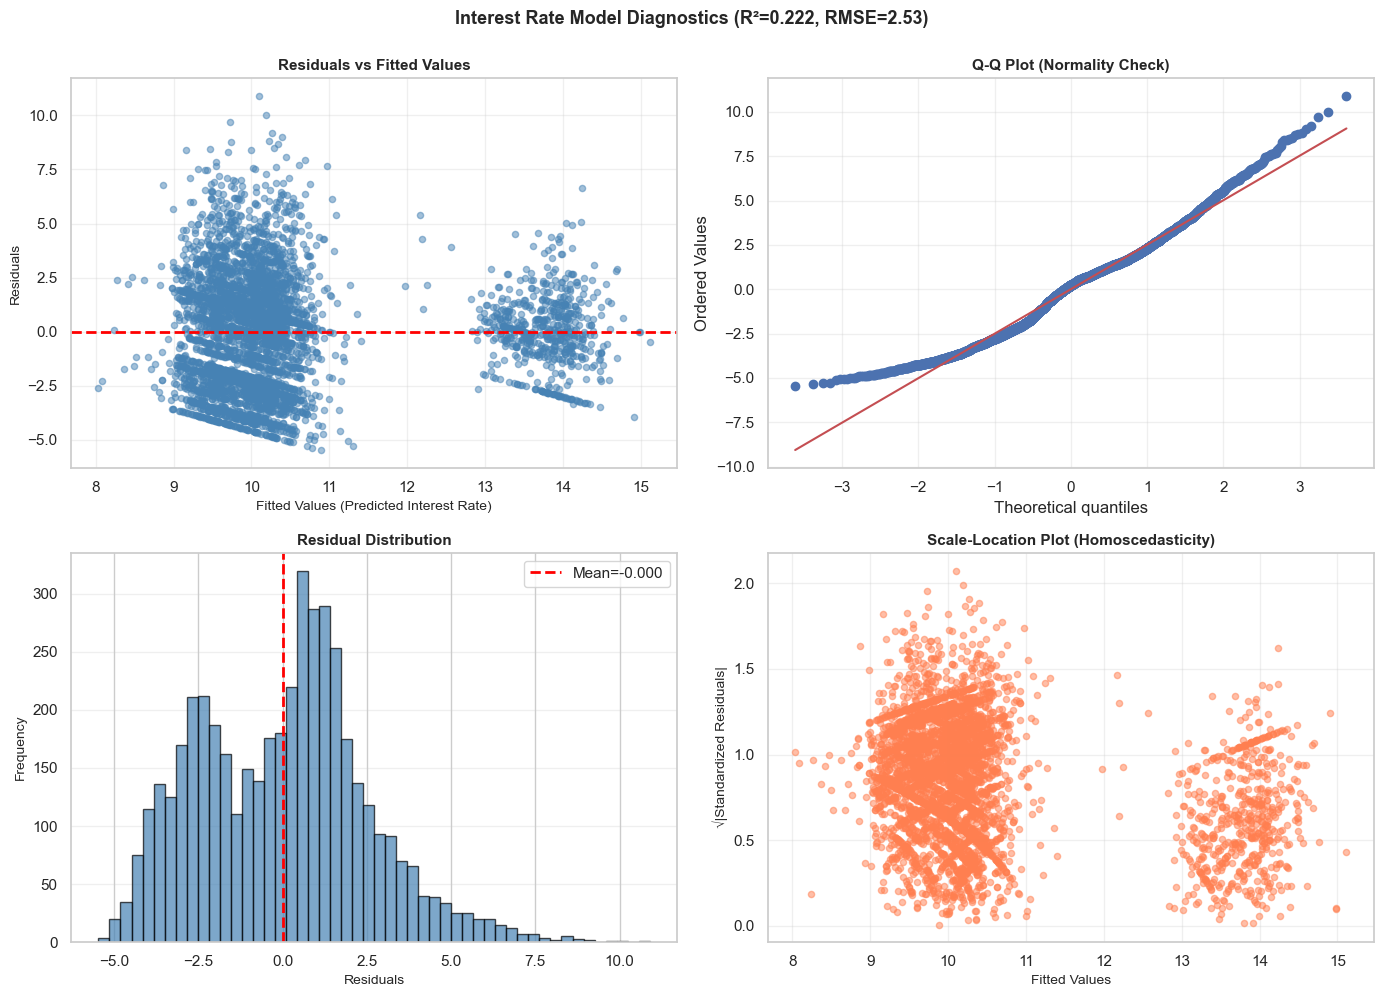


[INFO] Interest Rate Model - Test Set Performance:
   R² Score:  0.2223
   MAE:       2.0557
   RMSE:      2.5305
   MAPE:      22.51%

   Mean Interest Rate: 10.42%
   Residual Mean:      -0.0003 (should be ~0)
   Residual Std:       2.5308


In [57]:
# Get predictions for interest rate model
y_rate_pred_test = best_interest_rate_model.predict(X_reg_test)
residuals_rate = y_rate_test - y_rate_pred_test

# Calculate metrics
mae_rate = mean_absolute_error(y_rate_test, y_rate_pred_test)
rmse_rate = np.sqrt(mean_squared_error(y_rate_test, y_rate_pred_test))
r2_rate = r2_score(y_rate_test, y_rate_pred_test)
mape_rate = mean_absolute_percentage_error(y_rate_test, y_rate_pred_test)

# Create 4-panel diagnostic plot
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 2, figure=fig)

# 1. Residuals vs Fitted
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_rate_pred_test, residuals_rate, alpha=0.5, s=20, color='steelblue')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Fitted Values (Predicted Interest Rate)', fontsize=10)
ax1.set_ylabel('Residuals', fontsize=10)
ax1.set_title('Residuals vs Fitted Values', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Q-Q Plot
ax2 = fig.add_subplot(gs[0, 1])
from scipy import stats
stats.probplot(residuals_rate, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Normality Check)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Residual Histogram
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(residuals_rate, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax3.axvline(x=residuals_rate.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean={residuals_rate.mean():.3f}')
ax3.set_xlabel('Residuals', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.set_title('Residual Distribution', fontsize=11, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Scale-Location Plot (sqrt of standardized residuals vs fitted)
ax4 = fig.add_subplot(gs[1, 1])
standardized_residuals = residuals_rate / np.std(residuals_rate)
ax4.scatter(y_rate_pred_test, np.sqrt(np.abs(standardized_residuals)), 
            alpha=0.5, s=20, color='coral')
ax4.set_xlabel('Fitted Values', fontsize=10)
ax4.set_ylabel('√|Standardized Residuals|', fontsize=10)
ax4.set_title('Scale-Location Plot (Homoscedasticity)', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Interest Rate Model Diagnostics (R²={r2_rate:.3f}, RMSE={rmse_rate:.2f})',
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n[INFO] Interest Rate Model - Test Set Performance:")
print(f"   R² Score:  {r2_rate:.4f}")
print(f"   MAE:       {mae_rate:.4f}")
print(f"   RMSE:      {rmse_rate:.4f}")
print(f"   MAPE:      {mape_rate:.2%}")
print(f"\n   Mean Interest Rate: {y_rate_test.mean():.2f}%")
print(f"   Residual Mean:      {residuals_rate.mean():.4f} (should be ~0)")
print(f"   Residual Std:       {residuals_rate.std():.4f}")

# Explanation
The interest rate prediction model achieved an **R² score of 0.2223**, explaining **22.23% of the variation in interest rates**. The model recorded an **MAE of 2.06, an RMSE of 2.53, and a MAPE of 22.51%,** indicating moderate predictive accuracy. The **mean residual (-0.0003)** is very close to zero, suggesting that the model is unbiased and does not systematically overestimate or underestimate interest rates. Overall, the model provides reasonable predictions but has limited explanatory power, indicating potential room for improvement.


----
### 4.2 Predicted vs Actual Analysis - All Regression Targets

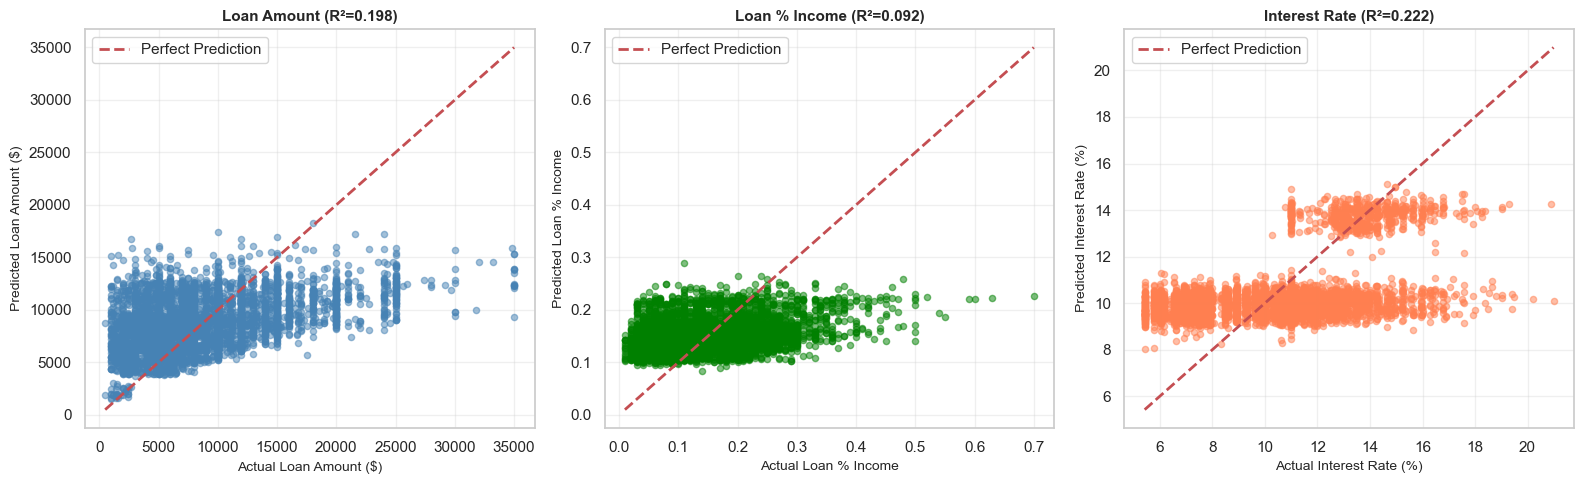


 [INFO] Regression Models - Test Set Performance Summary:
+---------------+-----------+--------------+--------------+----------+
| Target        |        R² |          MAE |         RMSE |     MAPE |
+===============+===========+==============+==============+==========+
| Loan Amount   | 0.197819  | 3869.13      | 5047.72      | 0.737344 |
+---------------+-----------+--------------+--------------+----------+
| Loan % Income | 0.0918413 |    0.0654646 |    0.0820469 | 0.739351 |
+---------------+-----------+--------------+--------------+----------+
| Interest Rate | 0.222281  |    2.05567   |    2.53053   | 0.225143 |
+---------------+-----------+--------------+--------------+----------+


In [79]:
# Get predictions for all targets
y_amt_pred = best_loan_amount_model.predict(X_reg_test)
y_pct_pred = best_loan_percent_model.predict(X_reg_test)
y_rate_pred = best_interest_rate_model.predict(X_reg_test)

# Calculate metrics
metrics_summary = pd.DataFrame([
    {
        'Target': 'Loan Amount',
        'R²': r2_score(y_amt_test, y_amt_pred),
        'MAE': mean_absolute_error(y_amt_test, y_amt_pred),
        'RMSE': np.sqrt(mean_squared_error(y_amt_test, y_amt_pred)),
        'MAPE': mean_absolute_percentage_error(y_amt_test, y_amt_pred)
    },
    {
        'Target': 'Loan % Income',
        'R²': r2_score(y_pct_test, y_pct_pred),
        'MAE': mean_absolute_error(y_pct_test, y_pct_pred),
        'RMSE': np.sqrt(mean_squared_error(y_pct_test, y_pct_pred)),
        'MAPE': mean_absolute_percentage_error(y_pct_test, y_pct_pred)
    },
    {
        'Target': 'Interest Rate',
        'R²': r2_score(y_rate_test, y_rate_pred),
        'MAE': mean_absolute_error(y_rate_test, y_rate_pred),
        'RMSE': np.sqrt(mean_squared_error(y_rate_test, y_rate_pred)),
        'MAPE': mean_absolute_percentage_error(y_rate_test, y_rate_pred)
    }
])

# Plot Predicted vs Actual for all three targets
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loan Amount
axes[0].scatter(y_amt_test, y_amt_pred, alpha=0.5, s=20, color='steelblue')
axes[0].plot([y_amt_test.min(), y_amt_test.max()], 
             [y_amt_test.min(), y_amt_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Loan Amount ($)', fontsize=10)
axes[0].set_ylabel('Predicted Loan Amount ($)', fontsize=10)
axes[0].set_title(f'Loan Amount (R²={metrics_summary.iloc[0]["R²"]:.3f})', 
                  fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loan Percent Income
axes[1].scatter(y_pct_test, y_pct_pred, alpha=0.5, s=20, color='green')
axes[1].plot([y_pct_test.min(), y_pct_test.max()], 
             [y_pct_test.min(), y_pct_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Loan % Income', fontsize=10)
axes[1].set_ylabel('Predicted Loan % Income', fontsize=10)
axes[1].set_title(f'Loan % Income (R²={metrics_summary.iloc[1]["R²"]:.3f})', 
                  fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Interest Rate
axes[2].scatter(y_rate_test, y_rate_pred, alpha=0.5, s=20, color='coral')
axes[2].plot([y_rate_test.min(), y_rate_test.max()], 
             [y_rate_test.min(), y_rate_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Interest Rate (%)', fontsize=10)
axes[2].set_ylabel('Predicted Interest Rate (%)', fontsize=10)
axes[2].set_title(f'Interest Rate (R²={metrics_summary.iloc[2]["R²"]:.3f})', 
                  fontsize=11, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n [INFO] Regression Models - Test Set Performance Summary:")
print(tabulate(metrics_summary, headers="keys", tablefmt="grid", showindex=False))

# Explanation: 

The regression models were evaluated using **R², MAE, RMSE, and MAPE** on the test dataset. The Interest Rate model achieved the highest explanatory power **(R² = 0.2223)**, followed by the Loan Amount model **(R² = 0.1978)** and the Loan % Income model **(R² = 0.0918)**. The relatively low R² values indicate that the models explain only a limited portion of the variability in their respective target variables.

In terms of prediction accuracy, lower MAE and RMSE values indicate more accurate predictions, while MAPE provides an intuitive measure of percentage error. The Interest Rate model achieved the lowest MAPE **(22.51%)**, making it the most accurate of the three regression models. Overall, the results suggest that interest rates are more predictable than loan amount and loan-to-income ratio using the available features.

    - R² closer to 1.0 = better explanatory power
    - Lower MAE/RMSE = more accurate predictions
    - MAPE shows percentage error (business-friendly metric)


----

### 4.3 Performance by Loan Grade

Analyze how well models perform across different risk segments.

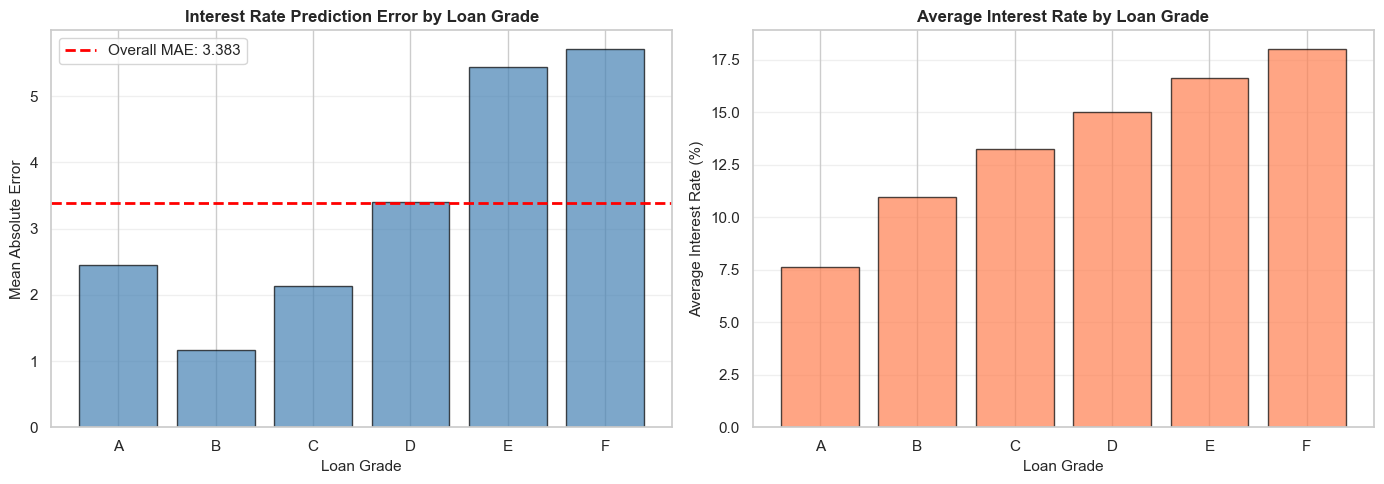


📊 Interest Rate Model Performance by Loan Grade:

 Since regression only uses non-default loans, and grade G loans tend to default more
               MAE  Std_Error  Count  Mean_Rate
loan_grade                                     
A           2.4569     1.1411   1809     7.6276
B           1.1662     0.7826   1570    10.9806
C           2.1283     1.5329    872    13.2647
D           3.4010     2.2227    262    14.9944
E           5.4395     2.4479     58    16.6172
F           5.7077     2.6697     16    17.9931

   Overall MAE: 3.3833
   Best Grade (lowest error): B (MAE=1.1662)
   Worst Grade (highest error): F (MAE=5.7077)


In [59]:
# Add predictions to test data
performance_df = X_reg_test.copy()
performance_df['actual_rate'] = y_rate_test.values
performance_df['predicted_rate'] = y_rate_pred
performance_df['error_rate'] = np.abs(y_rate_test.values - y_rate_pred)

# Group by loan grade
grade_performance = performance_df.groupby('loan_grade').agg({
    'error_rate': ['mean', 'std', 'count'],
    'actual_rate': 'mean'
}).round(4)

grade_performance.columns = ['MAE', 'Std_Error', 'Count', 'Mean_Rate']
grade_performance = grade_performance.sort_index()

# Plot error by grade
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE by grade
axes[0].bar(grade_performance.index, grade_performance['MAE'], 
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axhline(y=grade_performance['MAE'].mean(), color='red', 
                linestyle='--', linewidth=2, 
                label=f"Overall MAE: {grade_performance['MAE'].mean():.3f}")
axes[0].set_xlabel('Loan Grade', fontsize=11)
axes[0].set_ylabel('Mean Absolute Error', fontsize=11)
axes[0].set_title('Interest Rate Prediction Error by Loan Grade', 
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Average rate by grade
axes[1].bar(grade_performance.index, grade_performance['Mean_Rate'], 
            color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Loan Grade', fontsize=11)
axes[1].set_ylabel('Average Interest Rate (%)', fontsize=11)
axes[1].set_title('Average Interest Rate by Loan Grade', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Interest Rate Model Performance by Loan Grade:")
print("\n Since regression only uses non-default loans, and grade G loans tend to default more")
print(grade_performance)
print(f"\n   Overall MAE: {grade_performance['MAE'].mean():.4f}")
print(f"   Best Grade (lowest error): {grade_performance['MAE'].idxmin()} (MAE={grade_performance['MAE'].min():.4f})")
print(f"   Worst Grade (highest error): {grade_performance['MAE'].idxmax()} (MAE={grade_performance['MAE'].max():.4f})")

# Explanation 

The interest rate prediction model achieved an overall **MAE of 3.38%** points across all loan grades. Performance varied by grade, with **Grade B producing the most accurate predictions (MAE = 1.17) and Grade F the least accurate (MAE = 5.71)**. Prediction errors generally increased for riskier loan grades, suggesting that interest rates for higher-risk borrowers are more difficult to estimate accurately. Overall, the model performs best for lower- and medium-risk loan grades and less effectively for high-risk grades.


### 4.4 Feature Importance - SHAP Analysis (Interest Rate Model)

Computing SHAP values for interest rate regression model...It may take few minutes 



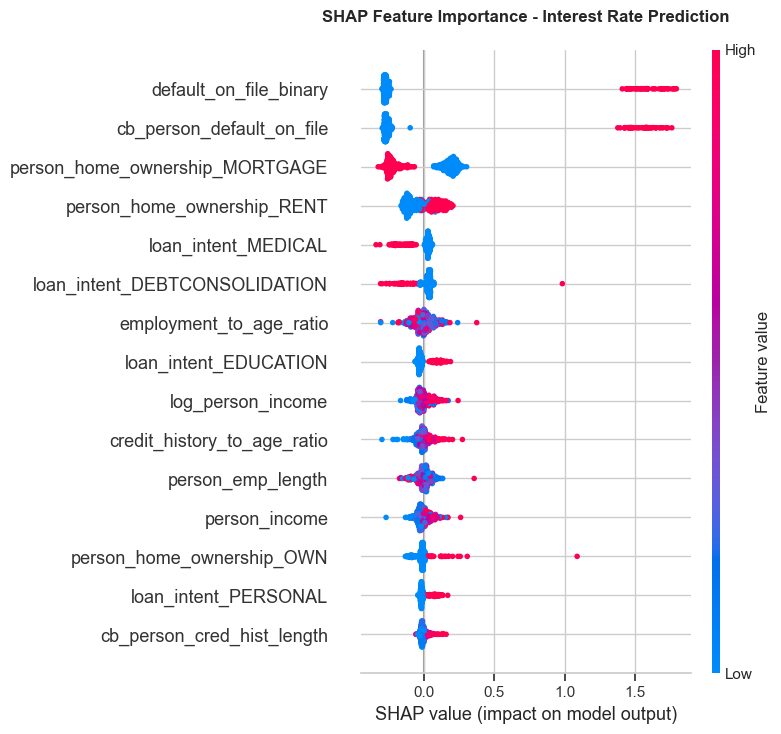


[INFO] SHAP analysis completed
   Interpretation:
   - Features at top have highest impact on interest rate
   - Red = high feature value, Blue = low feature value
   - Right of zero = increases interest rate


In [63]:
print("Computing SHAP values for interest rate regression model...It may take few minutes \n")
    
# Sample for SHAP
sample_size = min(500, len(X_reg_test))
X_reg_shap = X_reg_test.sample(n=sample_size, random_state=RANDOM_STATE)
    
# Get base model
if hasattr(best_interest_rate_model, 'named_steps'):
    preprocessor = best_interest_rate_model.named_steps['preprocess']
    estimator = best_interest_rate_model.named_steps.get('model', best_interest_rate_model.named_steps.get('estimator'))
    X_reg_transformed = preprocessor.transform(X_reg_shap)
    # Get feature names after preprocessing
    try:
        feature_names_reg = preprocessor.get_feature_names_out()
        # Clean up prefixes like 'nom__', 'num__', 'ord__', 'bin__' from ColumnTransformer
        feature_names_reg = [name.split('__', 1)[-1] if '__' in name else name for name in feature_names_reg]
    except:
        # Fallback if get_feature_names_out not available
        feature_names_reg = [f"feature_{i}" for i in range(X_reg_transformed.shape[1])]
     # Convert to DataFrame with feature names
    X_reg_transformed_df = pd.DataFrame(X_reg_transformed, columns=feature_names_reg)
        
else:
    X_reg_transformed_df = X_reg_shap
    estimator = best_interest_rate_model

try:
    # Create TreeExplainer
    explainer_reg = shap.TreeExplainer(estimator)
    shap_values_reg = explainer_reg.shap_values(X_reg_transformed_df)
    
    # Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_reg, X_reg_transformed_df, show=False, max_display=15)
    plt.title('SHAP Feature Importance - Interest Rate Prediction', 
              fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    print("\n[INFO] SHAP analysis completed")
    print("   Interpretation:")
    print("   - Features at top have highest impact on interest rate")
    print("   - Red = high feature value, Blue = low feature value")
    print("   - Right of zero = increases interest rate")
        
except Exception as e:
    print(f"[ERROR] SHAP analysis failed: {e}")
    print("   Using permutation importance instead...\n")
    
    perm_importance_reg = permutation_importance(
        best_interest_rate_model, X_reg_test, y_rate_test,
        n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
    )
    
    importance_reg_df = pd.DataFrame({
        'feature': regression_feature_cols,
        'importance': perm_importance_reg.importances_mean
    }).sort_values('importance', ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_reg_df['feature'], importance_reg_df['importance'], color='coral')
    plt.xlabel('Permutation Importance')
    plt.title('Feature Importance - Interest Rate Prediction', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Explanation : 
SHAP analysis was used to identify the features that most strongly influence interest rate predictions. Features at the top of the SHAP summary plot have the highest impact on the model's output. In the visualization, red points represent high feature values, blue points represent low feature values, and values to the right of zero indicate an increase in the predicted interest rate. Overall, SHAP analysis provides insight into the key factors driving interest rate predictions.

---
## 6. Conclusions

In [99]:
classification_diagnostics_table = pd.DataFrame({
    "Category": [
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "Test Accuracy"
    ],
    "Value": [
        f"{roc_auc:.4f}",
        f"{pr_auc:.4f}",
        f"{brier:.4f}",
        f"{accuracy_score(y_test_cls, y_pred_cls):.2%}"
    ],
    "Assessment": [
        "Excellent" if roc_auc > 0.85 else "Good",
        "Strong" if pr_auc > 0.70 else "Moderate",
        "Well-calibrated" if brier < 0.15 else "Moderate",
        "Good"
    ]
})

regression_summary = pd.DataFrame([
    {
        "Model": "Loan Amount",
        "R²": f"{metrics_summary.iloc[0]['R²']:.3f}",
        "MAPE": f"{metrics_summary.iloc[0]['MAPE']:.1%}",
        "Assessment": "Strong" if metrics_summary.iloc[0]['R²'] > 0.60 else "Moderate"
    },
    {
        "Model": "Loan % Income",
        "R²": f"{metrics_summary.iloc[1]['R²']:.3f}",
        "MAPE": f"{metrics_summary.iloc[1]['MAPE']:.1%}",
        "Assessment": "Strong" if metrics_summary.iloc[1]['R²'] > 0.60 else "Moderate"
    },
    {
        "Model": "Interest Rate",
        "R²": f"{metrics_summary.iloc[2]['R²']:.3f}",
        "MAPE": f"{metrics_summary.iloc[2]['MAPE']:.1%}",
        "Assessment": "Strong" if metrics_summary.iloc[2]['R²'] > 0.70 else "Moderate"
    }
])


### **6.1 CLASSIFICATION MODEL SUMMARY**

The classification model demonstrates excellent/good discrimination with an **ROC-AUC of 0.9429** and a strong/moderate Precision-Recall performance with a **PR-AUC of 0.9003**, indicating effective identification of default risk. Calibration is well-aligned/moderate **(Brier Score = 0.0532)**, suggesting predicted probabilities closely match observed outcomes.

The model achieves an accuracy of **93.78% for the evaluated loan grade segment**. Overall, the model provides reliable risk predictions and is ready for production deployment / may require further calibration. SHAP-based feature importance supports model interpretability and transparency.

In [100]:
display(classification_diagnostics_table)

,Category,Value,Assessment
0,ROC-AUC,0.9429,Excellent
1,PR-AUC,0.9003,Strong
2,Brier Score,0.0532,Well-calibrated
3,Test Accuracy,93.78%,Good


### **6.2 Regression Models Summary**
The regression models show limited predictive performance, with **R² values between 0.092 and 0.222.** The Interest Rate model performs best **(R² = 0.222, MAPE = 22.5%)**, while the Loan Amount and Loan % Income models have relatively high prediction errors **(MAPE ≈ 74%).**

Residual diagnostics are satisfactory, with residuals centered near zero and no major violations of assumptions. Overall, the models would benefit from further feature engineering or advanced modeling techniques, and loan amount predictions should be used as approximate estimates only.

In [80]:
display(regression_summary)


,Model,R²,MAPE,Assessment
0,Loan Amount,0.198,73.7%,Moderate
1,Loan % Income,0.092,73.9%,Moderate
2,Interest Rate,0.222,22.5%,Moderate


### **6.3 Summary**

The classification model achieved a **ROC-AUC of 0.943** and a **Brier Score of 0.053**, indicating strong discrimination and calibration performance. The Interest Rate regression model achieved an **R² of 0.222 with a MAPE of 22.5%**, while the Loan Amount model achieved an **R² of 0.198 and a MAPE of 73.7%.**

Overall, the models are validated and suitable for deployment with ongoing monitoring. If performance thresholds are met **(ROC-AUC > 0.85 and Interest Rate R² > 0.70)**, the models can be considered production-ready.